In [1]:
%matplotlib widget

# Model 4 - Upper conductive
## Noise effect

In [2]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
import pygimli as pg
from sklearn.metrics import root_mean_squared_error
from scipy.constants import mu_0
import math
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

from FDEM1D import LCModelling, FDEM1D, FDEM1DModelling #, LCModelling, FDEM1D_mdp

from matplotlib.colors import LogNorm
#plt.style.use('bmh')

L = LogNorm(vmin=0.001, vmax=1)
popts = {'norm': L}


In [3]:
# load model

model_true = np.load('models/model_d4_c2_uc.npy')
data_true = np.load('data/data_d4_c2_uc_nosort.npy')
model_lci = np.load('results/model_inv_d4_c2_uc_nosort_lam1.npy')
model_pwi = np.load('results/model_inv_d4_c2_uc_1D_nosort_lam1.npy')


In [4]:
# Add noise to the data

data_n1 = data_true + data_true * 0.01 * np.random.randn(40,18) 
data_n2 = data_true + data_true * 0.02 * np.random.randn(40,18)
data_n5 = data_true + data_true * 0.05 * np.random.randn(40,18)
data_n10 = data_true + data_true * 0.1 * np.random.randn(40,18)

In [5]:
# Invert datas n1 PIECEWISE

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n1.copy()

hw = 0
sw = 0

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n1 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n1 = np.array(m_pw_n1).reshape(np.shape(model_ini))
d_pw_n1 = np.array(inv.response)
d_pw_n1 = d_pw_n1.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:43:15 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc82d524900>


18/11/25 - 09:43:15 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [6]:
# Invert datas n1 PIECEWISE

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n2.copy()

hw = 0
sw = 0

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n2 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n2 = np.array(m_pw_n2).reshape(np.shape(model_ini))
d_pw_n2 = np.array(inv.response)
d_pw_n2 = d_pw_n2.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:43:24 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc82c88dd00>


18/11/25 - 09:43:24 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [7]:
# Invert datas n1 PIECEWISE

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n5.copy()

hw = 0
sw = 0

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n5 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n5 = np.array(m_pw_n5).reshape(np.shape(model_ini))
d_pw_n5 = np.array(inv.response)
d_pw_n5 = d_pw_n5.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:43:32 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc82c88ec00>


18/11/25 - 09:43:32 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [8]:
# Invert datas n1 PIECEWISE

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n10.copy()

hw = 0
sw = 0

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n10 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n10 = np.array(m_pw_n10).reshape(np.shape(model_ini))
d_pw_n10 = np.array(inv.response)
d_pw_n10 = d_pw_n10.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:43:41 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc82d525e90>


18/11/25 - 09:43:41 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [9]:
model_true[:,1:] = model_true[:,1:]*1000
model_pwi[:,1:] = model_pwi[:,1:] *1000
m_pw_n1[:,1:] = m_pw_n1[:,1:]*1000
m_pw_n2[:,1:] = m_pw_n2[:,1:]*1000
m_pw_n5[:,1:] = m_pw_n5[:,1:]*1000
m_pw_n10[:,1:] = m_pw_n10[:,1:]*1000

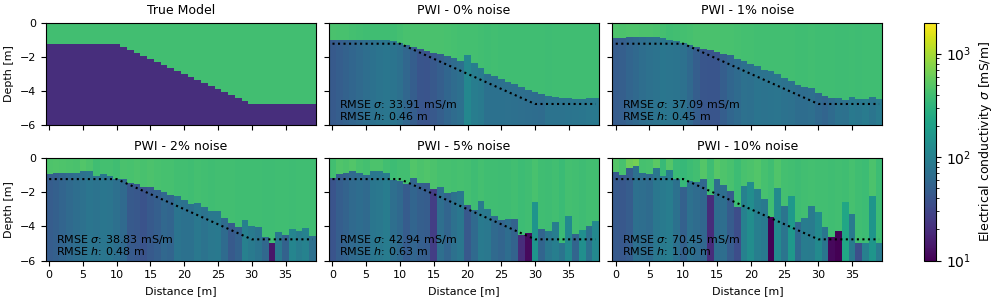

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(10,3), sharey=True, sharex=True, layout='constrained')
inputs = {'zMax' : 6,
          'colorBar': False,
          'cMin' : 10,
          'cMax' : 2000,
         }
_, c = showStitchedModels(model_true, ax=ax[0,0], **inputs)
showStitchedModels(model_pwi, ax=ax[0,1], **inputs)
showStitchedModels(m_pw_n1, ax=ax[0,2], **inputs)
showStitchedModels(m_pw_n2, ax=ax[1,0], **inputs)
showStitchedModels(m_pw_n5, ax=ax[1,1], **inputs)
showStitchedModels(m_pw_n10, ax=ax[1,2], **inputs)

ax[0,0].set_title('True Model', fontsize=9)

RMSE_pw_h = root_mean_squared_error(model_true[:,0], model_pwi[:,0])
RMSE_pw_s = root_mean_squared_error(model_true[:,1:], model_pwi[:,1:])
ax[0,1].set_title(f'PWI - 0% noise', fontsize=9)
ax[0,1].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_s:.2f} mS/m', fontsize=8) 
ax[0,1].text(1,-5.7, f'RMSE $h$: {RMSE_pw_h:.2f} m', fontsize=8)
ax[0,1].plot( -model_true[:,0], ':k')

ax[0,2].set_title('PWI - 1% noise', fontsize=9)
RMSE_pw_n1_h = root_mean_squared_error(model_true[:,0], m_pw_n1[:,0])
RMSE_pw_n1_s = root_mean_squared_error(model_true[:,1:], m_pw_n1[:,1:])
ax[0,2].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n1_s:.2f} mS/m', fontsize=8)
ax[0,2].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n1_h:.2f} m', fontsize=8)
ax[0,2].plot( -model_true[:,0], ':k')

ax[1,0].set_title('PWI - 2% noise', fontsize=9)
RMSE_pw_n2_h = root_mean_squared_error(model_true[:,0], m_pw_n2[:,0])
RMSE_pw_n2_s = root_mean_squared_error(model_true[:,1:], m_pw_n2[:,1:])
ax[1,0].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n2_s:.2f} mS/m', fontsize=8)
ax[1,0].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n2_h:.2f} m', fontsize=8)
ax[1,0].plot( -model_true[:,0], ':k')

ax[1,1].set_title('PWI - 5% noise', fontsize=9)
RMSE_pw_n5_h = root_mean_squared_error(model_true[:,0], m_pw_n5[:,0])
RMSE_pw_n5_s = root_mean_squared_error(model_true[:,1:], m_pw_n5[:,1:])
ax[1,1].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n5_s:.2f} mS/m', fontsize=8)
ax[1,1].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n5_h:.2f} m', fontsize=8)
ax[1,1].plot( -model_true[:,0], ':k')

ax[1,2].set_title('PWI - 10% noise', fontsize=9)
RMSE_pw_n10_h = root_mean_squared_error(model_true[:,0], m_pw_n10[:,0])
RMSE_pw_n10_s = root_mean_squared_error(model_true[:,1:], m_pw_n10[:,1:])
ax[1,2].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n10_s:.2f} mS/m', fontsize=8)
ax[1,2].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n10_h:.2f} m', fontsize=8)
ax[1,2].plot( -model_true[:,0], ':k')

ax[-1,0].set_xlabel('Distance [m]', fontsize=8)
ax[-1,1].set_xlabel('Distance [m]', fontsize=8)
ax[-1,2].set_xlabel('Distance [m]', fontsize=8)
ax[0,0].set_ylabel('Depth [m]', fontsize=8)
ax[1,0].set_ylabel('Depth [m]', fontsize=8)

for a in ax.ravel():
    a.tick_params(labelsize=8)

cb = fig.colorbar(c, ax=ax.ravel().tolist(), location='right')
cb.set_label("Electrical conductivity $\sigma$ [mS/m]", fontsize=9)
plt.savefig('figures/PWI_noise.eps', format='eps')

In [14]:
# LCI

# Invert datas n1 

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n1.copy()

hw = 1
sw = 1

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n1 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n1 = np.array(m_pw_n1).reshape(np.shape(model_ini))
d_pw_n1 = np.array(inv.response)
d_pw_n1 = d_pw_n1.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:48:28 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc821987a60>


18/11/25 - 09:48:28 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [15]:
# Invert datas n1 LCI

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n2.copy()

hw = 1
sw = 1

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n2 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n2 = np.array(m_pw_n2).reshape(np.shape(model_ini))
d_pw_n2 = np.array(inv.response)
d_pw_n2 = d_pw_n2.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:48:37 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc8222827f0>


18/11/25 - 09:48:37 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [16]:
# Invert datas n1 

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n5.copy()

hw = 1
sw = 1

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n5 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n5 = np.array(m_pw_n5).reshape(np.shape(model_ini))
d_pw_n5 = np.array(inv.response)
d_pw_n5 = d_pw_n5.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:48:45 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc8216f6430>


18/11/25 - 09:48:46 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [17]:
# Invert datas n1 

model_ini = model_true.copy()
model_ini[:,0] = 3
model_ini[:,1:] = 0.5

# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling)

data = data_n10.copy()

hw = 1
sw = 1

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_pw_n10 = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_pw_n10 = np.array(m_pw_n10).reshape(np.shape(model_ini))
d_pw_n10 = np.array(inv.response)
d_pw_n10 = d_pw_n10.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


18/11/25 - 09:48:54 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fc8222827f0>


18/11/25 - 09:48:54 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [18]:
#model_true[:,1:] = model_true[:,1:]*1000
#model_pwi[:,1:] = model_pwi[:,1:] *1000
model_lci[:,1:] = model_lci[:,1:]*1000
m_pw_n1[:,1:] = m_pw_n1[:,1:]*1000
m_pw_n2[:,1:] = m_pw_n2[:,1:]*1000
m_pw_n5[:,1:] = m_pw_n5[:,1:]*1000
m_pw_n10[:,1:] = m_pw_n10[:,1:]*1000

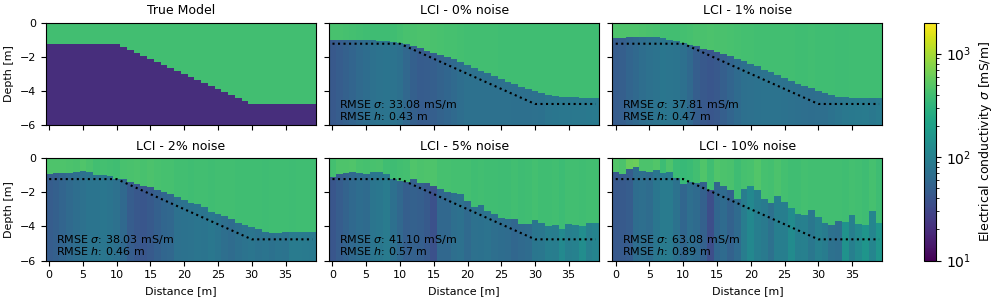

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(10,3), sharey=True, sharex=True, layout='constrained')
inputs = {'zMax' : 6,
          'colorBar': False,
          'cMin' : 10,
          'cMax' : 2000,
         }
_, c = showStitchedModels(model_true, ax=ax[0,0], **inputs)
showStitchedModels(model_lci, ax=ax[0,1], **inputs)
showStitchedModels(m_pw_n1, ax=ax[0,2], **inputs)
showStitchedModels(m_pw_n2, ax=ax[1,0], **inputs)
showStitchedModels(m_pw_n5, ax=ax[1,1], **inputs)
showStitchedModels(m_pw_n10, ax=ax[1,2], **inputs)

ax[0,0].set_title('True Model', fontsize=9)

RMSE_pw_h = root_mean_squared_error(model_true[:,0], model_lci[:,0])
RMSE_pw_s = root_mean_squared_error(model_true[:,1:], model_lci[:,1:])
ax[0,1].set_title(f'LCI - 0% noise', fontsize=9)
ax[0,1].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_s:.2f} mS/m', fontsize=8) 
ax[0,1].text(1,-5.7, f'RMSE $h$: {RMSE_pw_h:.2f} m', fontsize=8)
ax[0,1].plot( -model_true[:,0], ':k')

ax[0,2].set_title('LCI - 1% noise', fontsize=9)
RMSE_pw_n1_h = root_mean_squared_error(model_true[:,0], m_pw_n1[:,0])
RMSE_pw_n1_s = root_mean_squared_error(model_true[:,1:], m_pw_n1[:,1:])
ax[0,2].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n1_s:.2f} mS/m', fontsize=8)
ax[0,2].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n1_h:.2f} m', fontsize=8)
ax[0,2].plot( -model_true[:,0], ':k')

ax[1,0].set_title('LCI - 2% noise', fontsize=9)
RMSE_pw_n2_h = root_mean_squared_error(model_true[:,0], m_pw_n2[:,0])
RMSE_pw_n2_s = root_mean_squared_error(model_true[:,1:], m_pw_n2[:,1:])
ax[1,0].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n2_s:.2f} mS/m', fontsize=8)
ax[1,0].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n2_h:.2f} m', fontsize=8)
ax[1,0].plot( -model_true[:,0], ':k')

ax[1,1].set_title('LCI - 5% noise', fontsize=9)
RMSE_pw_n5_h = root_mean_squared_error(model_true[:,0], m_pw_n5[:,0])
RMSE_pw_n5_s = root_mean_squared_error(model_true[:,1:], m_pw_n5[:,1:])
ax[1,1].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n5_s:.2f} mS/m', fontsize=8)
ax[1,1].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n5_h:.2f} m', fontsize=8)
ax[1,1].plot( -model_true[:,0], ':k')

ax[1,2].set_title('LCI - 10% noise', fontsize=9)
RMSE_pw_n10_h = root_mean_squared_error(model_true[:,0], m_pw_n10[:,0])
RMSE_pw_n10_s = root_mean_squared_error(model_true[:,1:], m_pw_n10[:,1:])
ax[1,2].text(1, -5, f'RMSE $\sigma$: {RMSE_pw_n10_s:.2f} mS/m', fontsize=8)
ax[1,2].text(1,-5.7, f'RMSE $h$: {RMSE_pw_n10_h:.2f} m', fontsize=8)
ax[1,2].plot( -model_true[:,0], ':k')

ax[-1,0].set_xlabel('Distance [m]', fontsize=8)
ax[-1,1].set_xlabel('Distance [m]', fontsize=8)
ax[-1,2].set_xlabel('Distance [m]', fontsize=8)
ax[0,0].set_ylabel('Depth [m]', fontsize=8)
ax[1,0].set_ylabel('Depth [m]', fontsize=8)

for a in ax.ravel():
    a.tick_params(labelsize=8)

cb = fig.colorbar(c, ax=ax.ravel().tolist(), location='right')
cb.set_label("Electrical conductivity $\sigma$ [mS/m]", fontsize=9)

plt.savefig('figures/LCI_noise.eps', format='eps')